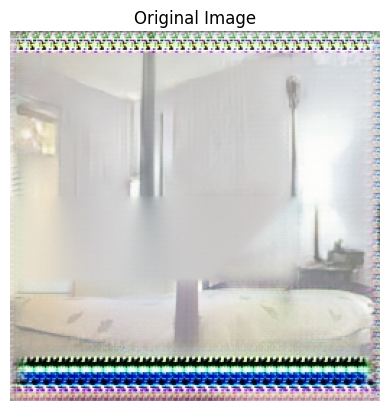


image 1/1 C:\Users\vaibh\Desktop\stablle_disffusion_hough\blurred_image.jpg: 640x640 (no detections), 19.5ms
Speed: 10.0ms preprocess, 19.5ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


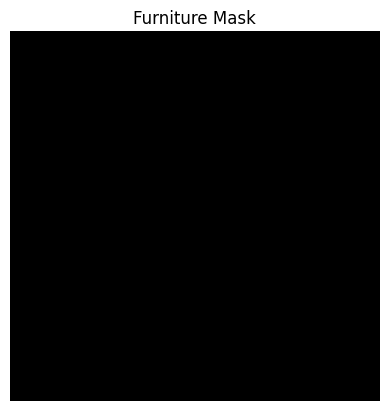

✅ Encoded C:\Users\vaibh\Desktop\stablle_disffusion_hough\blurred_image.jpg - size: 75300
✅ Encoded mask.png - size: 188
❌ ERROR: Encoded image or mask is too small — check files.
❌ LaMa request failed: 400 Client Error: BAD REQUEST for url: http://localhost:8080/inpaint
🔍 Response: <!doctype html>
<html lang=en>
<title>400 Bad Request</title>
<h1>Bad Request</h1>
<p>The browser (or proxy) sent a request that this server could not understand.</p>



c:\Users\vaibh\Desktop\stablle_disffusion_hough\venv310\lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
unet\diffusion_pytorch_model.safetensors not found
Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

In [ ]:
import os
import cv2
import requests
import base64
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from diffusers import StableDiffusionInpaintPipeline
import io

# === Paths ===
image_path = r"C:\Users\vaibh\Desktop\stablle_disffusion_hough\image_after_detection.jpg"  # 👈 Change this to your input image path
mask_path = "mask.png"
lama_url = "http://localhost:8080/inpaint"

# === Load Image ===
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')
plt.title("Original Image")
plt.show()

# === YOLOv8 Furniture Detection ===
model = YOLO("yolov8n.pt")
results = model(image_path)

furniture_classes = ["bed", "chair", "couch", "table", "tv", "refrigerator", "dining table"]
mask = np.zeros(image.shape[:2], dtype=np.uint8)

for result in results:
    for box in result.boxes.data:
        x1, y1, x2, y2, conf, cls = box.tolist()
        class_name = model.names[int(cls)]
        if class_name in furniture_classes:
            cv2.rectangle(mask, (int(x1), int(y1)), (int(x2), int(y2)), 255, -1)

# ✅ FIX: Save proper grayscale mask
Image.fromarray(mask).convert("L").save(mask_path)

# === Show Mask Preview ===
plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.title("Furniture Mask")
plt.show()

# === Base64 Encoding ===
def encode_image(path):
    try:
        with open(path, "rb") as f:
            data = f.read()
            encoded = base64.b64encode(data).decode("utf-8")
            print(f"✅ Encoded {path} - size: {len(encoded)}")
            return encoded
    except Exception as e:
        print(f"❌ Error encoding {path}:", e)
        return ""

image_b64 = encode_image(image_path)
mask_b64 = encode_image(mask_path)

if len(image_b64) < 10000 or len(mask_b64) < 1000:
    print("❌ ERROR: Encoded image or mask is too small — check files.")
    exit()

# === Send to LaMa Cleaner API ===
try:
    response = requests.post(lama_url, json={
        "image": image_b64,
        "mask": mask_b64,
        "model": "lama"
    })
    response.raise_for_status()
    print("✅ LaMa API call successful!")

    lama_result = Image.open(io.BytesIO(response.content))
    lama_result.save("lama_result.jpg")
    lama_result.show()

except requests.exceptions.RequestException as e:
    print("❌ LaMa request failed:", e)
    print("🔍 Response:", response.text)
    exit()

# === Stable Diffusion Inpainting ===
try:
    pipe = StableDiffusionInpaintPipeline.from_pretrained("runwayml/stable-diffusion-inpainting").to("cuda")
    prompt = "A modern, clean bedroom with wooden flooring and soft lighting"
    sd_result = pipe(
        prompt=prompt,
        image=lama_result.convert("RGB"),
        mask_image=Image.open(mask_path).convert("L")
    ).images[0]

    sd_result.save("final_output.jpg")
    plt.imshow(sd_result)
    plt.axis('off')
    plt.title("Stable Diffusion Final Output")
    plt.show()

except Exception as e:
    print("⚠️ Stable Diffusion failed:", e)
